In [60]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI

load_dotenv()  # 加载.env文件里的变量
# print(os.getenv("DEEPSEEK_API_KEY"))  # 现在可以正常读取了

llm = ChatOpenAI(
        model="deepseek-chat",  # 使用的模型名称，目前官方推荐用 'deepseek-chat'
        api_key=os.getenv("DEEPSEEK_API_KEY"),  # 你的 DeepSeek API Key
        base_url="https://api.deepseek.com/v1",  # DeepSeek API 地址
        temperature=0,
    )

In [61]:
from typing import Optional, Union

from openai import BaseModel
from pydantic import Field
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage,AnyMessage,AIMessage, ToolMessage,SystemMessage

class WeatherInfo(BaseModel):
    location:str=Field(description="the location of weather info")

class UserInfo(BaseModel):
    """Extracted user information, such as name,age, phone,email"""
    name:str=Field(description="The name of user")
    age:Optional[int]=Field(description="The age of user")
    email:str=Field(description="The email of user")
    phone:Optional[str]=Field(description="The phone of user")

class RealTimeInfo(BaseModel):
    """fetch real time infor"""
    query:str=Field(description="the query to fetch real time info")

class ConversationalResponse(BaseModel):
    response:str=Field(description="chat response from LLM")    

class FinalResponse(BaseModel):
    final_output:Union[UserInfo,ConversationalResponse,WeatherInfo,RealTimeInfo]
    

parser=PydanticOutputParser(pydantic_object=FinalResponse)
prompt=ChatPromptTemplate.from_messages([
    ('system','解析用户输入并提取个人信息 {format_instructions}'),
    ('human','{query}')
])



In [62]:
from langgraph.prebuilt import ToolNode


@tool(args_schema=RealTimeInfo)
def fetch_real_time_info(query):
    """fetch real time info based on query"""
    print('fetch_real_time_info',query)
    return {'messages':['小米汽车真是好，九八九八不得了']}

@tool(args_schema=WeatherInfo)
def get_weather_info(location):
    """get the weather info based on location."""
    print('get_weather_info',location)
    return {'messages':['天气晴']}

@tool(args_schema=UserInfo)
def insert_db(name, age, email, phone):
    """insert user info into db"""
    print('userInfo:', name, age, email, phone)
    return {'messages':['插入成功']}

tools=[fetch_real_time_info,get_weather_info,insert_db]
toolNode=ToolNode(tools)

In [63]:
model_with_tools=llm.bind_tools(tools)


prompt=prompt.partial(format_instructions=parser.get_format_instructions())
structured_llm=prompt | llm | parser

In [64]:
print(model_with_tools.kwargs)
model_with_tools.invoke('北京的天气').tool_calls


{'tools': [{'type': 'function', 'function': {'name': 'fetch_real_time_info', 'description': 'fetch real time info based on query', 'parameters': {'properties': {}, 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'get_weather_info', 'description': 'get the weather info based on location.', 'parameters': {'properties': {}, 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'insert_db', 'description': 'insert user info into db', 'parameters': {'properties': {}, 'type': 'object'}}}]}


[{'name': 'get_weather_info',
  'args': {},
  'id': 'call_00_1Ca5lT2pITLBTiv5KpXz5707',
  'type': 'tool_call'}]

In [65]:
from langgraph._internal._constants import CONF, CONFIG_KEY_RUNTIME
from langgraph.runtime import Runtime

def chat_with_model(state):
    messages=state['messages']
    response=structured_llm.invoke(messages)
    return {'messages':[AIMessage(content=str(response))],
            'structured_output':response.final_output}

def execute_tool(state):
    print('execute_tool',state)
    # config = {CONF: {CONFIG_KEY_RUNTIME: Runtime()}}
    # result=model_with_tools.invoke(str(state['structured_output']))
    # print('execute_tool',model_with_tools.invoke(str(state['structured_output'])).tool_calls)
    # 非常重要，通过下面的代码，可以保证result中的tool_calls有参数，否则，有时候tool_calls中的args是空对象，导致报错
    result = model_with_tools.invoke(
        [HumanMessage(content=f"请调用对应工具，参数如下：{state['structured_output']}")]
    )
    # response=toolNode.invoke({"messages":[result,state['messages']]},config)
    
    tool_calls=result.tool_calls
    results=[]
    tool_map={t.name: t for t in tools}
    for t in tool_calls:
        if not t['name'] in tool_map:
            result='bad tool name, retry'
        else:
            result=tool_map[t['name']].invoke(t['args'])
        results.append(ToolMessage(tool_call_id=t['id'],name=t['name'],content=str(result)))
    return {'messages':[results]}

def final_answer(state):
    messages=state['messages']
    response=llm.invoke(messages)
    print('final_answer',response)
    return {'messages':[response]}

SYSTEM_PROMPT="""
Please summarize the information obtained so far and generate a professional response. Note, please reply in Chinese.
"""


def natural_response(state):
    """generate final language responses"""
    messages=state['messages'][-1][-1]
    messages=[SystemMessage(content=SYSTEM_PROMPT),HumanMessage(content=messages.content)]
    response=llm.invoke(messages)
    
    return {'messages':[response]}


In [66]:
from typing import Any, List, TypedDict, Optional
from typing_extensions import Annotated
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage
import operator
from langgraph.graph import START, StateGraph, END



class AgentState(TypedDict):
    messages: Annotated[List[AnyMessage], operator.add]
    structured_output: Optional[Any]  # 存放 FinalResponse.final_output，和消息管道分离
    
def routing_function(state:AgentState):
    final_output=state['structured_output']
    if isinstance(final_output,ConversationalResponse):
        return 'final_answer'
    else:
        return 'execute_tool'

builder=StateGraph(AgentState)

builder.add_node('chat_with_model',chat_with_model)
builder.add_node('execute_tool',execute_tool)
builder.add_node('final_answer',final_answer)
builder.add_node('natural_response',natural_response)

builder.add_edge(START,'chat_with_model')
builder.add_conditional_edges('chat_with_model',routing_function,
                              {
                                  'final_answer':'final_answer',
                                  'execute_tool':'execute_tool'
                              })

builder.add_edge("execute_tool","natural_response")
builder.add_edge("final_answer","natural_response")

builder.add_edge("natural_response",END)


graph=builder.compile()

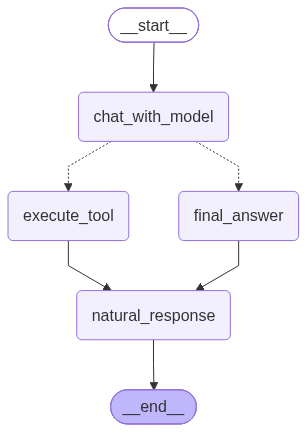

In [67]:
from IPython.display import display,Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
result=graph.invoke({'messages':[HumanMessage(content='小米汽车最新消息')]})
print(result['messages'][-1].content)

# query="小米汽车最新消息"
# input_message={"query":[HumanMessage(content=query)]}

# result=graph.invoke(input_message)

execute_tool {'messages': [HumanMessage(content='小米汽车最新消息', additional_kwargs={}, response_metadata={}), AIMessage(content="FinalResponse(final_output=RealTimeInfo(query='小米汽车最新消息'))", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])], 'structured_output': RealTimeInfo(query='小米汽车最新消息')}
fetch_real_time_info 小米汽车最新消息
{'messages': [HumanMessage(content='小米汽车最新消息', additional_kwargs={}, response_metadata={}), AIMessage(content="FinalResponse(final_output=RealTimeInfo(query='小米汽车最新消息'))", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), [ToolMessage(content="{'messages': ['小米汽车真是好，九八九八不得了']}", name='fetch_real_time_info', tool_call_id='call_00_W4ieCx3TPuX6oKwFzRzv5658')], AIMessage(content='根据目前获得的信息，您提到的“小米汽车真是好，九八九八不得了”是一句带有民间顺口溜风格的赞美语，其中“九八九八”可能指代价格（如9.98万元）或某种特定配置。但截至目前，小米官方并未正式公布旗下汽车产品的具体售价、详细参数或上市时间。小米汽车项目仍在推进中，相关技术研发、生产资质及市场策略等信息均以官方发布为准。\n\n建议您关注小米公司官方渠道（如官网、官方微博、发布会）获取最新、最准确的资讯。同时，对于网络上的非官方言论，请保持理性判断，避免传播未经证实的信息。如

In [70]:
print(result['messages'][-1].content)

根据目前获得的信息，您提到的“小米汽车真是好，九八九八不得了”是一句带有民间顺口溜风格的赞美语，其中“九八九八”可能指代价格（如9.98万元）或某种特定配置。但截至目前，小米官方并未正式公布旗下汽车产品的具体售价、详细参数或上市时间。小米汽车项目仍在推进中，相关技术研发、生产资质及市场策略等信息均以官方发布为准。

建议您关注小米公司官方渠道（如官网、官方微博、发布会）获取最新、最准确的资讯。同时，对于网络上的非官方言论，请保持理性判断，避免传播未经证实的信息。如果您有具体问题（如车型、性能、价格区间等），欢迎提供更详细的内容，我将尽力为您整理公开资料并给出客观分析。


In [71]:
result=graph.invoke({'messages':[HumanMessage(content='大连的天气')]})
print(result['messages'][-1].content)

execute_tool {'messages': [HumanMessage(content='大连的天气', additional_kwargs={}, response_metadata={}), AIMessage(content="FinalResponse(final_output=WeatherInfo(location='大连'))", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])], 'structured_output': WeatherInfo(location='大连')}
get_weather_info 大连
根据目前掌握的信息，天气状况为晴朗。建议您根据此情况合理安排出行与户外活动，并注意防晒补水。如需更详细的预报（如温度、风力等），请提供具体地点或时间，以便进一步查询。


In [72]:
result=graph.invoke({'messages':[HumanMessage(content='我叫奥特曼，今年38岁，邮箱地址是aoteman@qq.com,电话是123123123')]})
print(result['messages'][-1].content)

execute_tool {'messages': [HumanMessage(content='我叫奥特曼，今年38岁，邮箱地址是aoteman@qq.com,电话是123123123', additional_kwargs={}, response_metadata={}), AIMessage(content="FinalResponse(final_output=UserInfo(name='奥特曼', age=38, email='aoteman@qq.com', phone='123123123'))", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])], 'structured_output': UserInfo(name='奥特曼', age=38, email='aoteman@qq.com', phone='123123123')}
userInfo: 奥特曼 38 aoteman@qq.com 123123123
根据目前获得的信息，系统已成功完成数据插入操作，返回状态为“插入成功”。这意味着相关数据已按预期写入目标数据库或存储系统，未出现错误或异常。

后续如需进一步验证数据完整性、执行查询或进行其他操作，请提供具体需求，我将协助处理。


In [ ]:
result